# Phase 1: Binary Classification (2 Classes &mdash; Attack vs. Benign)

**Capstone Project: IoT Intrusion Detection System (CICIoT2023)**

### Objectives:
1. Train and evaluate multiple model families to distinguish between **Legitimate (Benign)** and **Malicious (Attack)** traffic.
2. Address class imbalance (Benign traffic accounts for ~7.6% of instances in the dataset).
3. Benchmark performance across classical linear baselines (`LogisticRegression`), tree ensembles (`RandomForest`), gradient boosted trees (`LightGBM`, `XGBoost`), and Deep Neural Networks (`PyTorch Tabular DNN`).
4. Profile **inference latency** (microseconds per flow) to evaluate IoT edge-gateway deployment feasibility.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from src.config import SAMPLE_FILE, TABLES_DIR, FIGURES_DIR, MODELS_DIR, BINARY_CLASSES
from src.preprocessing import prepare_dataset
from src.evaluate import evaluate_predictions, measure_inference_latency, plot_confusion_matrix, plot_binary_roc_pr
from src.models import get_model

sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data & Prepare Preprocessing Pipeline

In [2]:
df = pd.read_csv(SAMPLE_FILE)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

X_train, X_test, y_train, y_test, class_names, scaler = prepare_dataset(
    df, target_type="binary", test_size=0.2, random_state=42, scale_features=True
)

print(f"X_train Shape : {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape  : {X_test.shape}  | y_test Shape : {y_test.shape}")
print(f"Train Distribution -> Attack (1): {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%) | Benign (0): {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"Test Distribution  -> Attack (1): {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%) | Benign (0): {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")

Loaded dataset: 529,562 rows x 40 columns


X_train Shape : (423649, 39) | y_train Shape: (423649,)
X_test Shape  : (105913, 39)  | y_test Shape : (105913,)
Train Distribution -> Attack (1): 391,649 (92.4%) | Benign (0): 32,000 (7.6%)
Test Distribution  -> Attack (1): 97,913 (92.4%) | Benign (0): 8,000 (7.6%)


## 2. Load & Display Benchmark Results Across All Models

In [3]:
benchmark_csv = TABLES_DIR / "binary_models_benchmark.csv"
if benchmark_csv.exists():
    results_df = pd.read_csv(benchmark_csv)
    print("\n===== Phase 1 Binary Benchmark Results =====")
    display_table = results_df.copy()
    display_table['Accuracy'] = display_table['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
    display_table['Macro F1'] = display_table['Macro F1'].apply(lambda x: f"{x:.4f}")
    display_table['Weighted F1'] = display_table['Weighted F1'].apply(lambda x: f"{x:.4f}")
    display_table['ROC-AUC'] = display_table['ROC-AUC'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    display_table['PR-AUC'] = display_table['PR-AUC'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    display_table['Latency (us/flow)'] = display_table['Latency (us/flow)'].apply(lambda x: f"{x:.2f} us")
    display_table['Throughput (flows/s)'] = display_table['Throughput (flows/s)'].apply(lambda x: f"{x:,} fps")
    print(tabulate(display_table, headers="keys", tablefmt="github", showindex=False))
else:
    print("Benchmark table not found. Run 'python -m src.train_binary' first.")


===== Phase 1 Binary Benchmark Results =====
| Model               | Accuracy   |   Macro F1 |   Weighted F1 |   Macro Precision |   Macro Recall |   ROC-AUC |   PR-AUC |   Train Time (s) | Latency (us/flow)   | Throughput (flows/s)   |
|---------------------|------------|------------|---------------|-------------------|----------------|-----------|----------|------------------|---------------------|------------------------|
| xgboost             | 95.28%     |     0.8133 |        0.9503 |          0.851127 |       0.784031 |    0.9748 |   0.9979 |             3.61 | 1.05 us             | 954,681 fps            |
| pytorch_dnn         | 94.66%     |     0.7872 |        0.9435 |          0.824861 |       0.758799 |    0.9651 |   0.9969 |            57.34 | 14.50 us            | 68,950 fps             |
| random_forest       | 89.75%     |     0.7648 |        0.9148 |          0.709673 |       0.930267 |    0.9753 |   0.998  |             7.39 | 8.98 us             | 111,314 fps        

## 3. Comparative Metric Visualizations

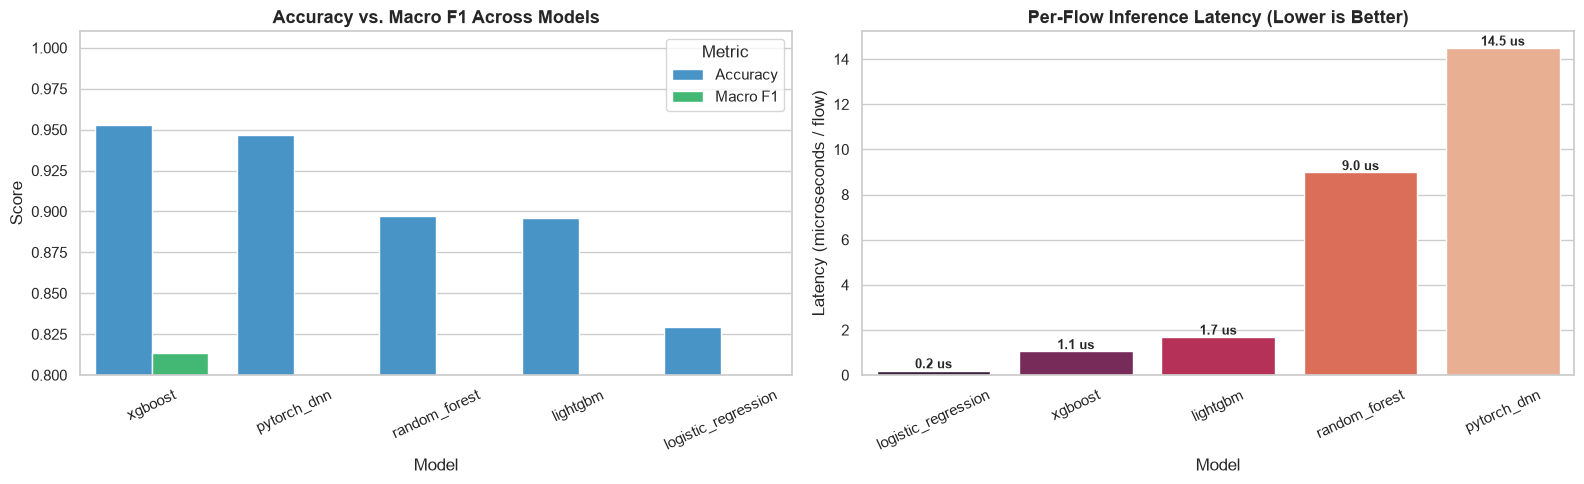

In [4]:
if benchmark_csv.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Macro F1 vs Accuracy
    plot_df = results_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'Macro F1'], var_name='Metric', value_name='Score')
    sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', ax=axes[0], palette=['#3498db', '#2ecc71'])
    axes[0].set_title("Accuracy vs. Macro F1 Across Models", fontsize=13, fontweight='bold')
    axes[0].set_ylim([0.80, 1.01])
    axes[0].tick_params(axis='x', rotation=25)
    
    # Plot 2: Inference Latency (Microseconds per flow)
    sns.barplot(data=results_df.sort_values(by='Latency (us/flow)'), x='Model', y='Latency (us/flow)', hue='Model', ax=axes[1], palette='rocket', legend=False)
    axes[1].set_title("Per-Flow Inference Latency (Lower is Better)", fontsize=13, fontweight='bold')
    axes[1].set_ylabel("Latency (microseconds / flow)")
    axes[1].tick_params(axis='x', rotation=25)
    for i, row in enumerate(results_df.sort_values(by='Latency (us/flow)').itertuples()):
        axes[1].text(i, row._10 + 0.1, f"{row._10:.1f} us", ha='center', fontsize=9, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

## 4. Confusion Matrix Heatmaps (Normalized by True Class)

Found 5 confusion matrix figures:
Displaying: binary_cm_lightgbm.png


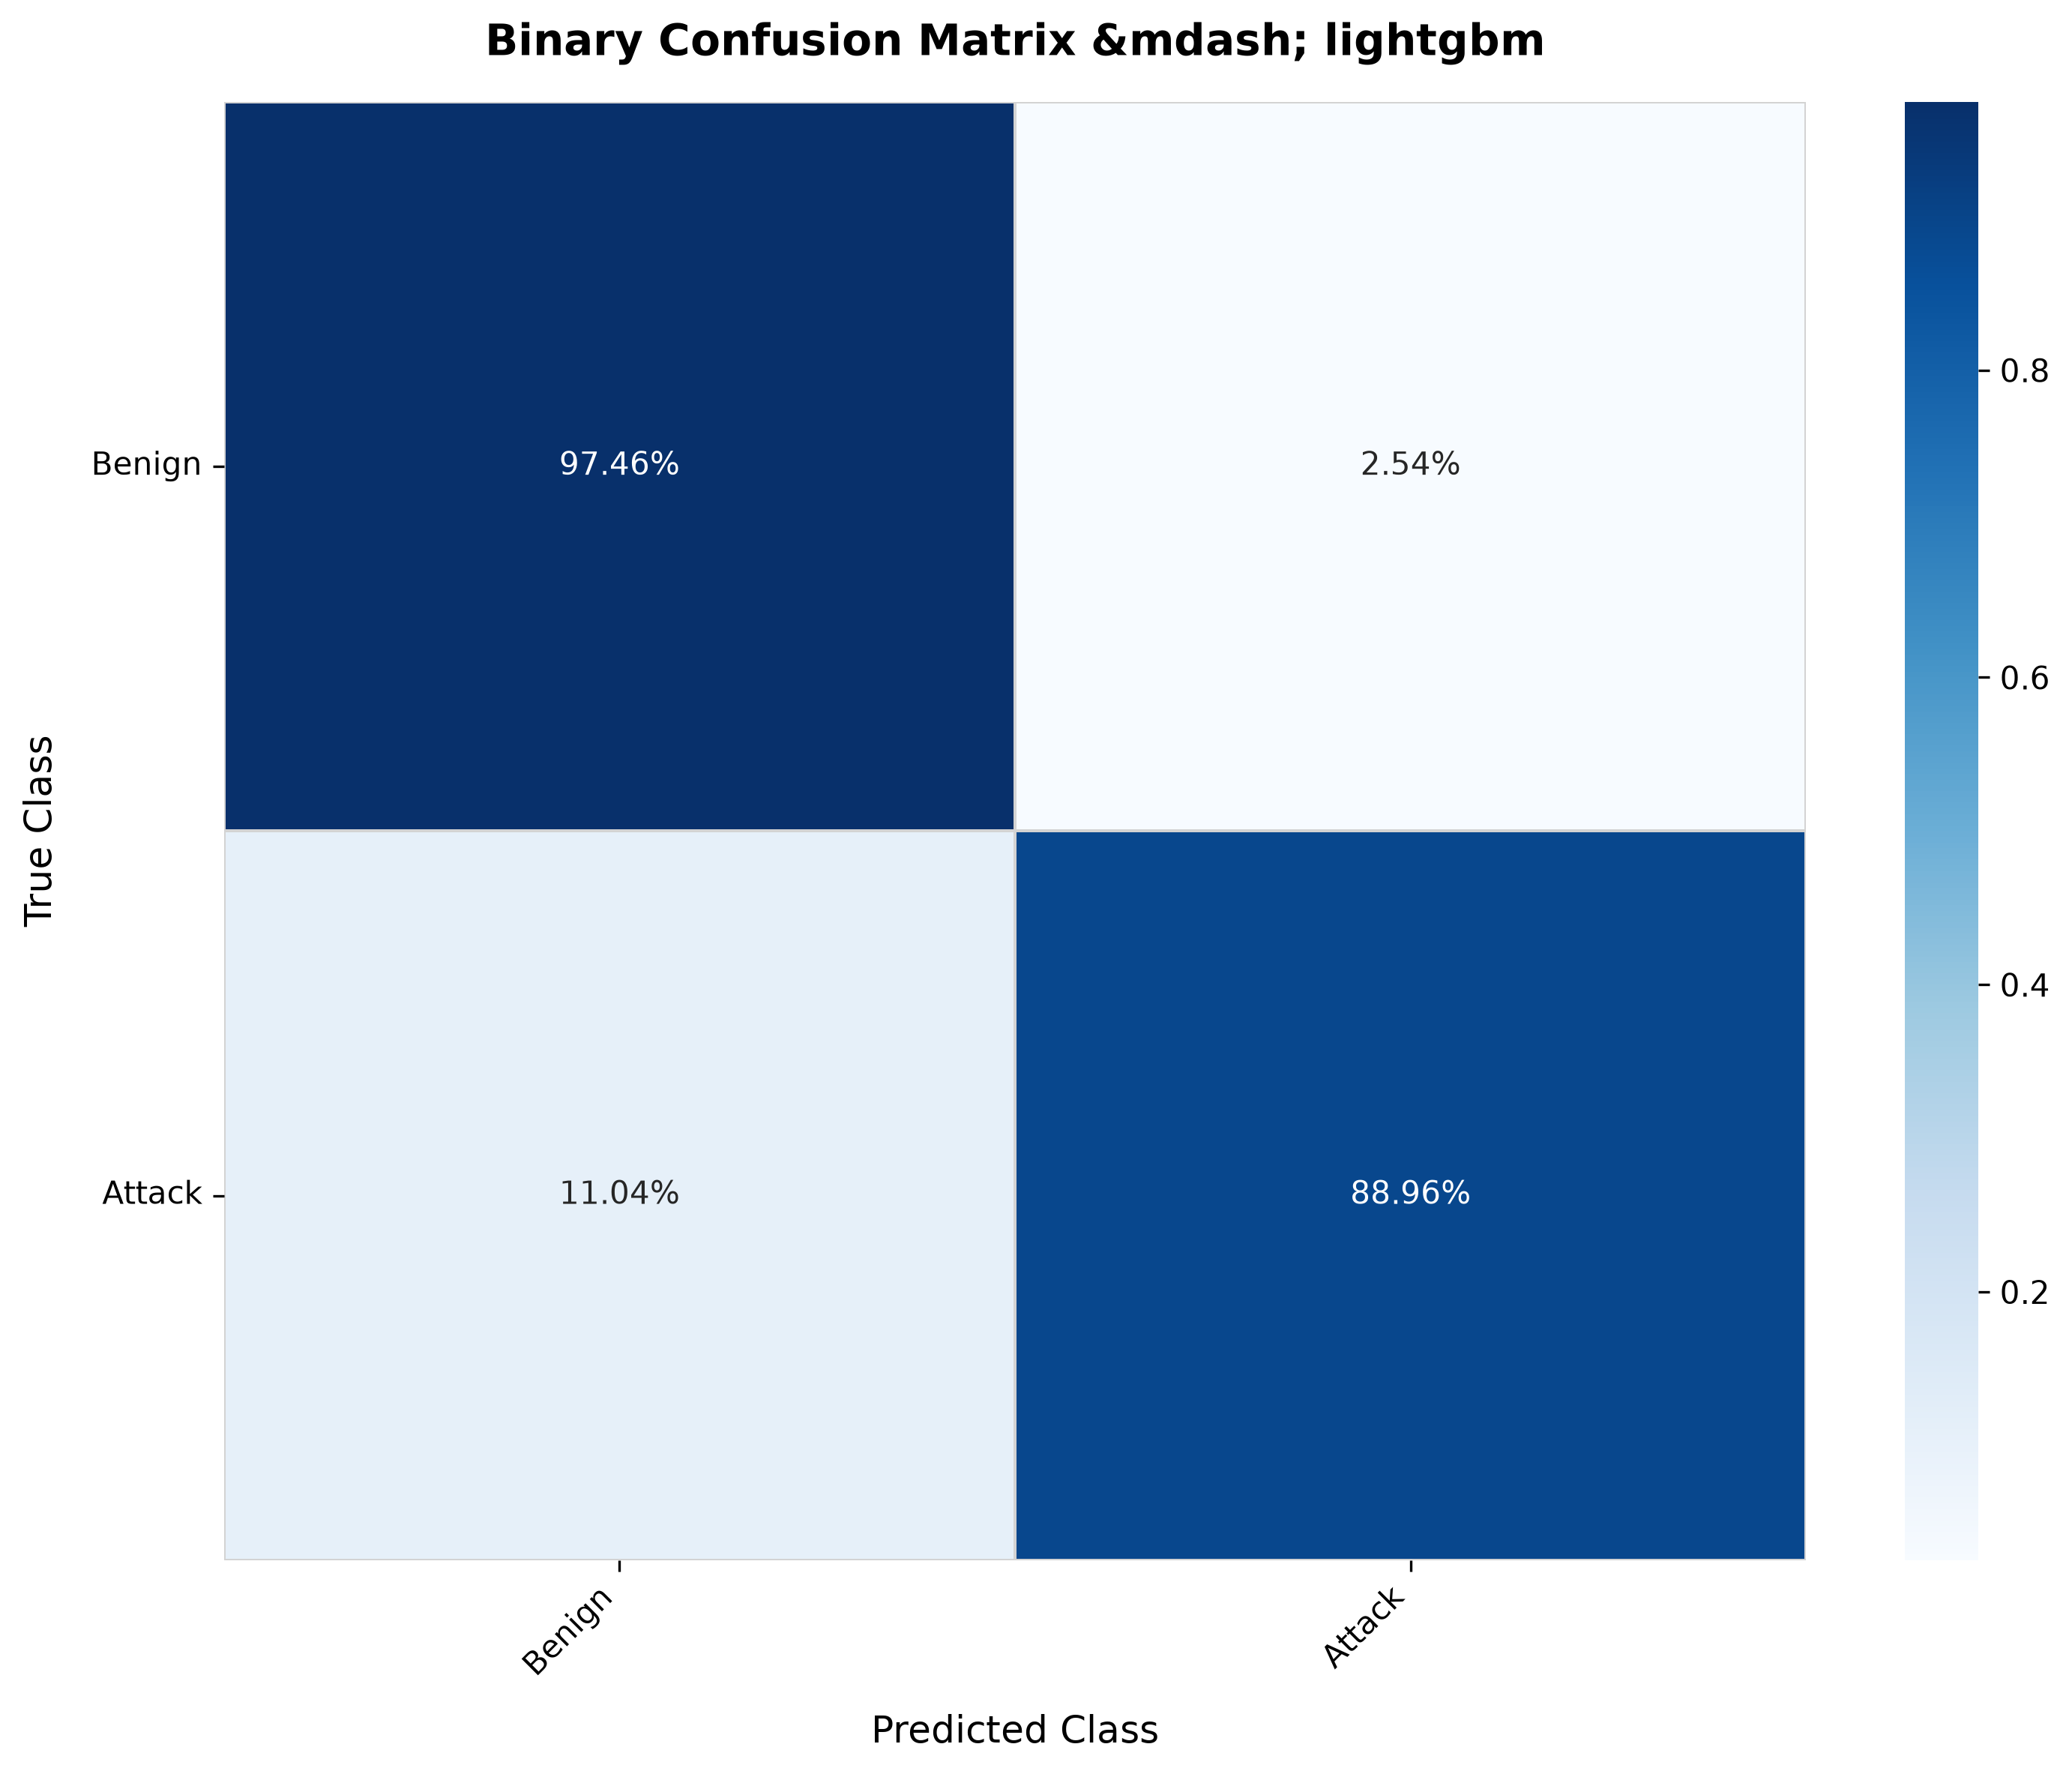

Displaying: binary_cm_logistic_regression.png


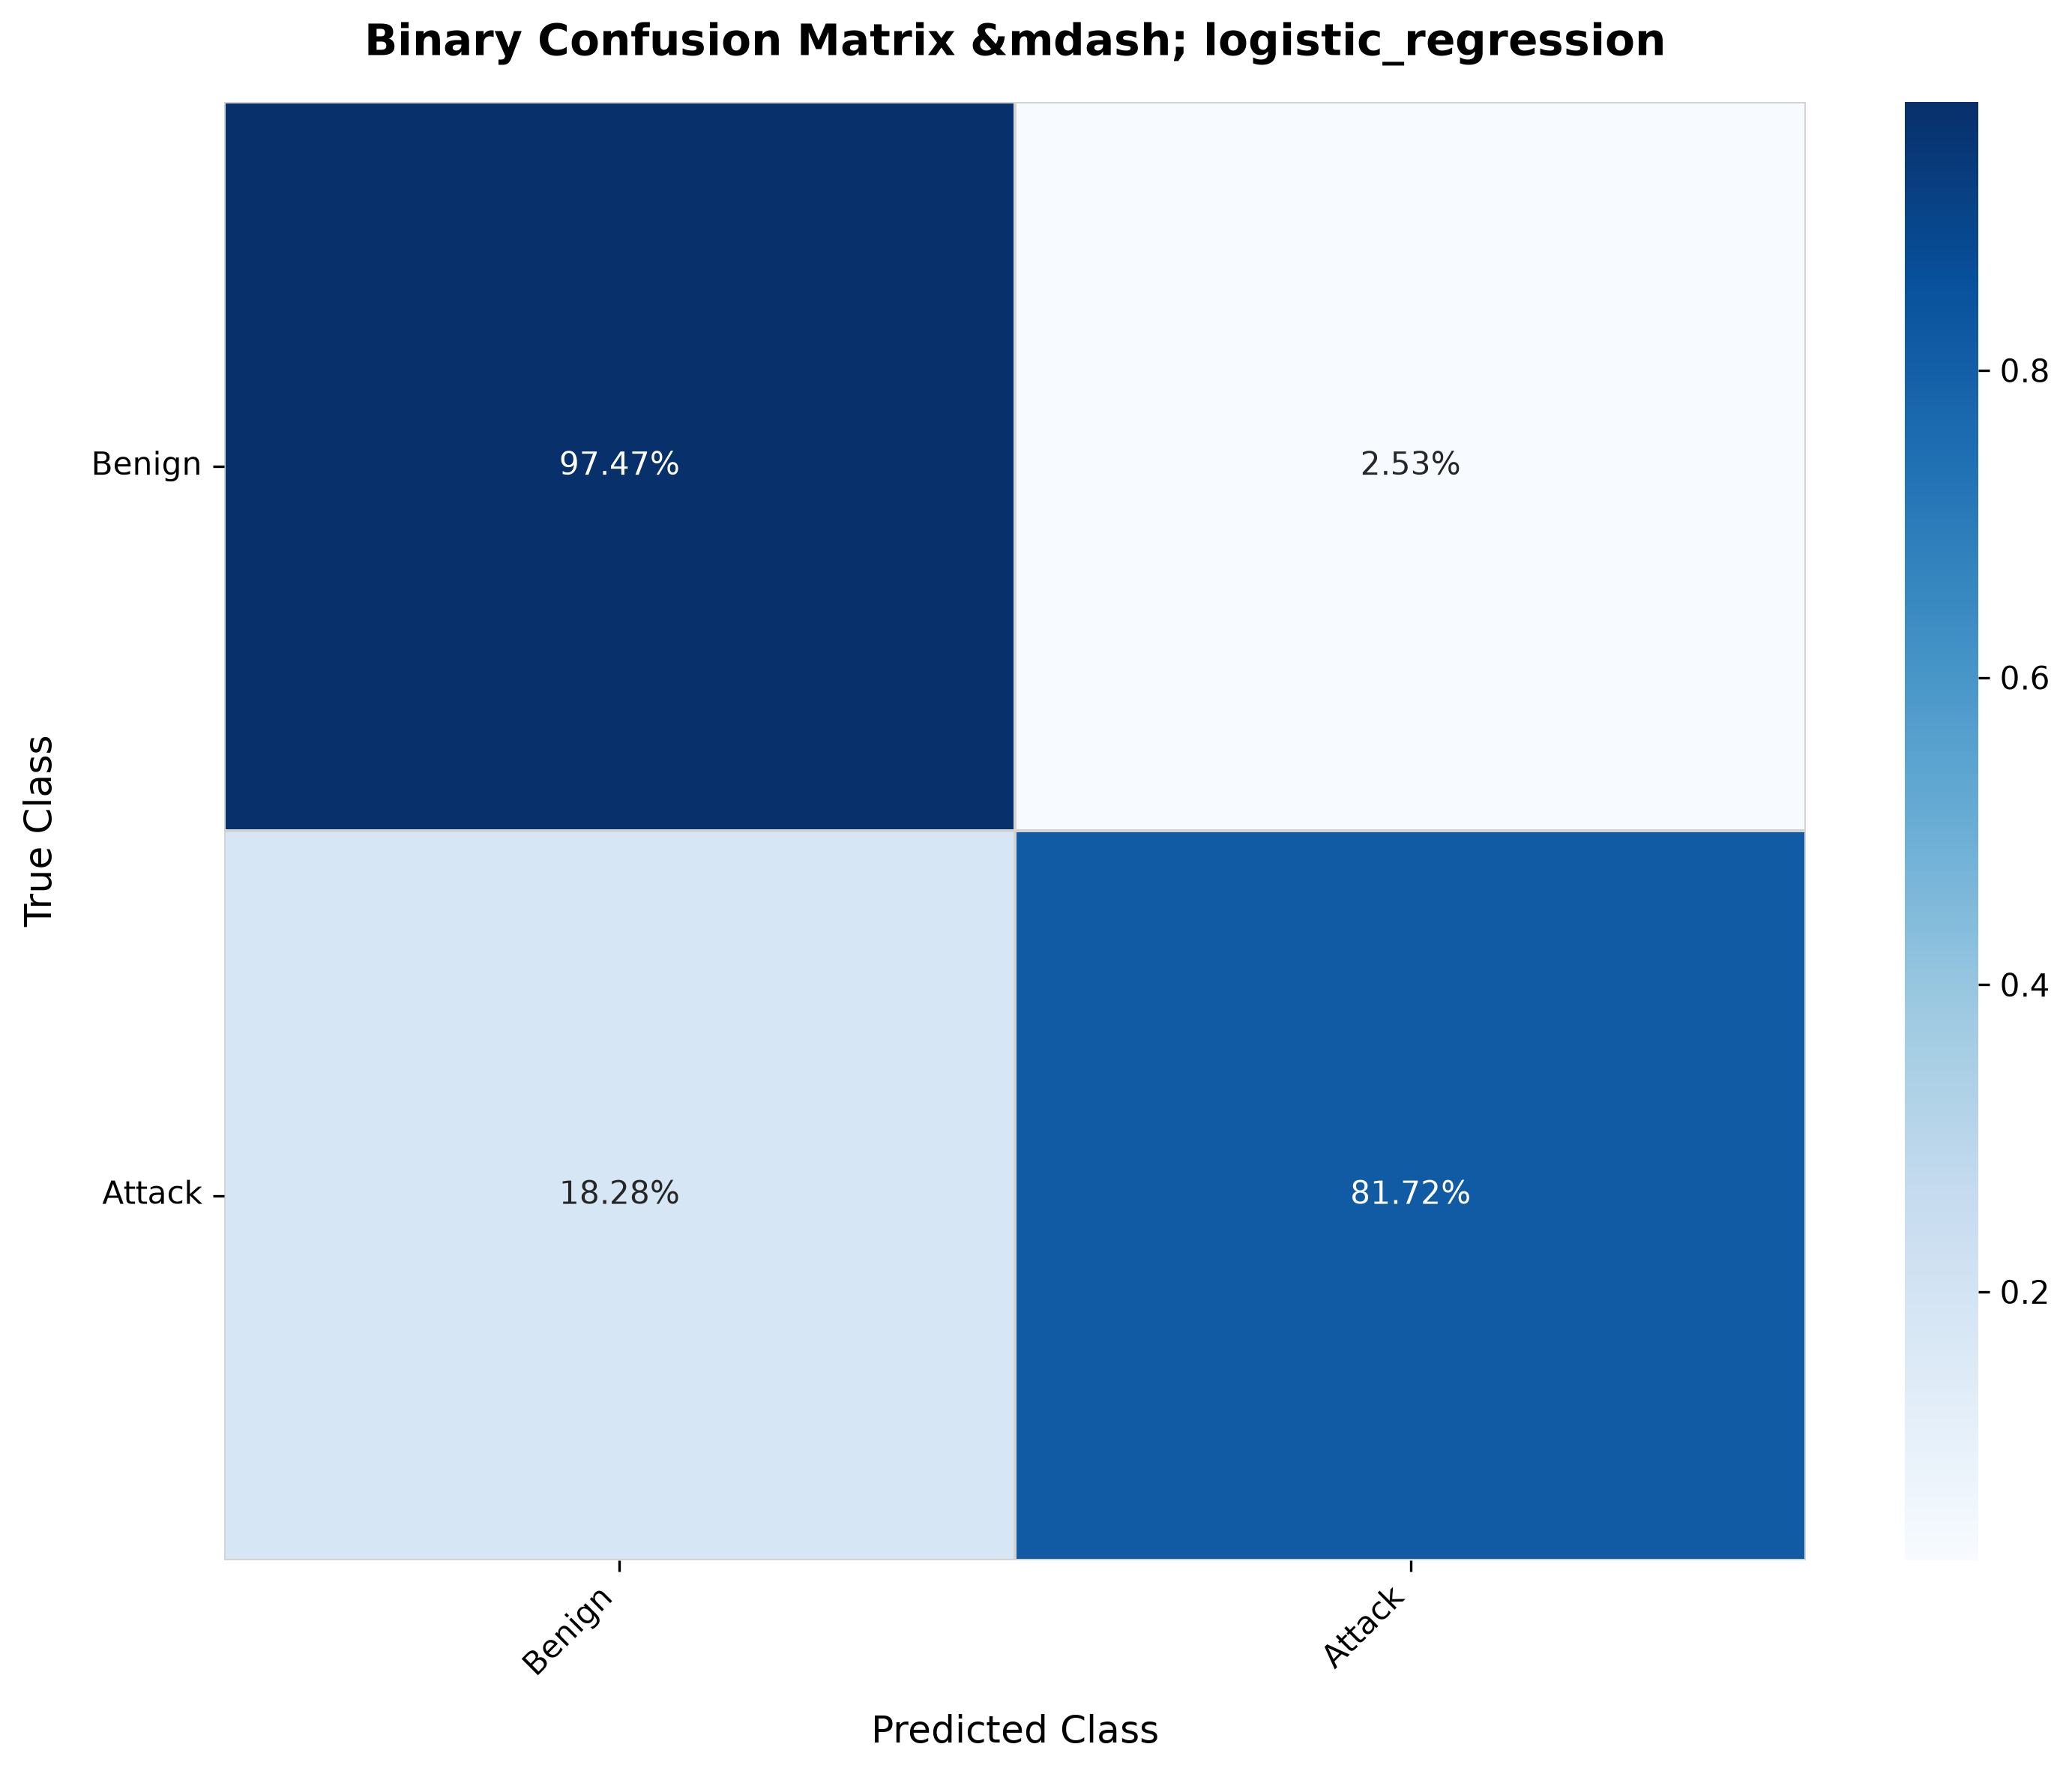

Displaying: binary_cm_pytorch_dnn.png


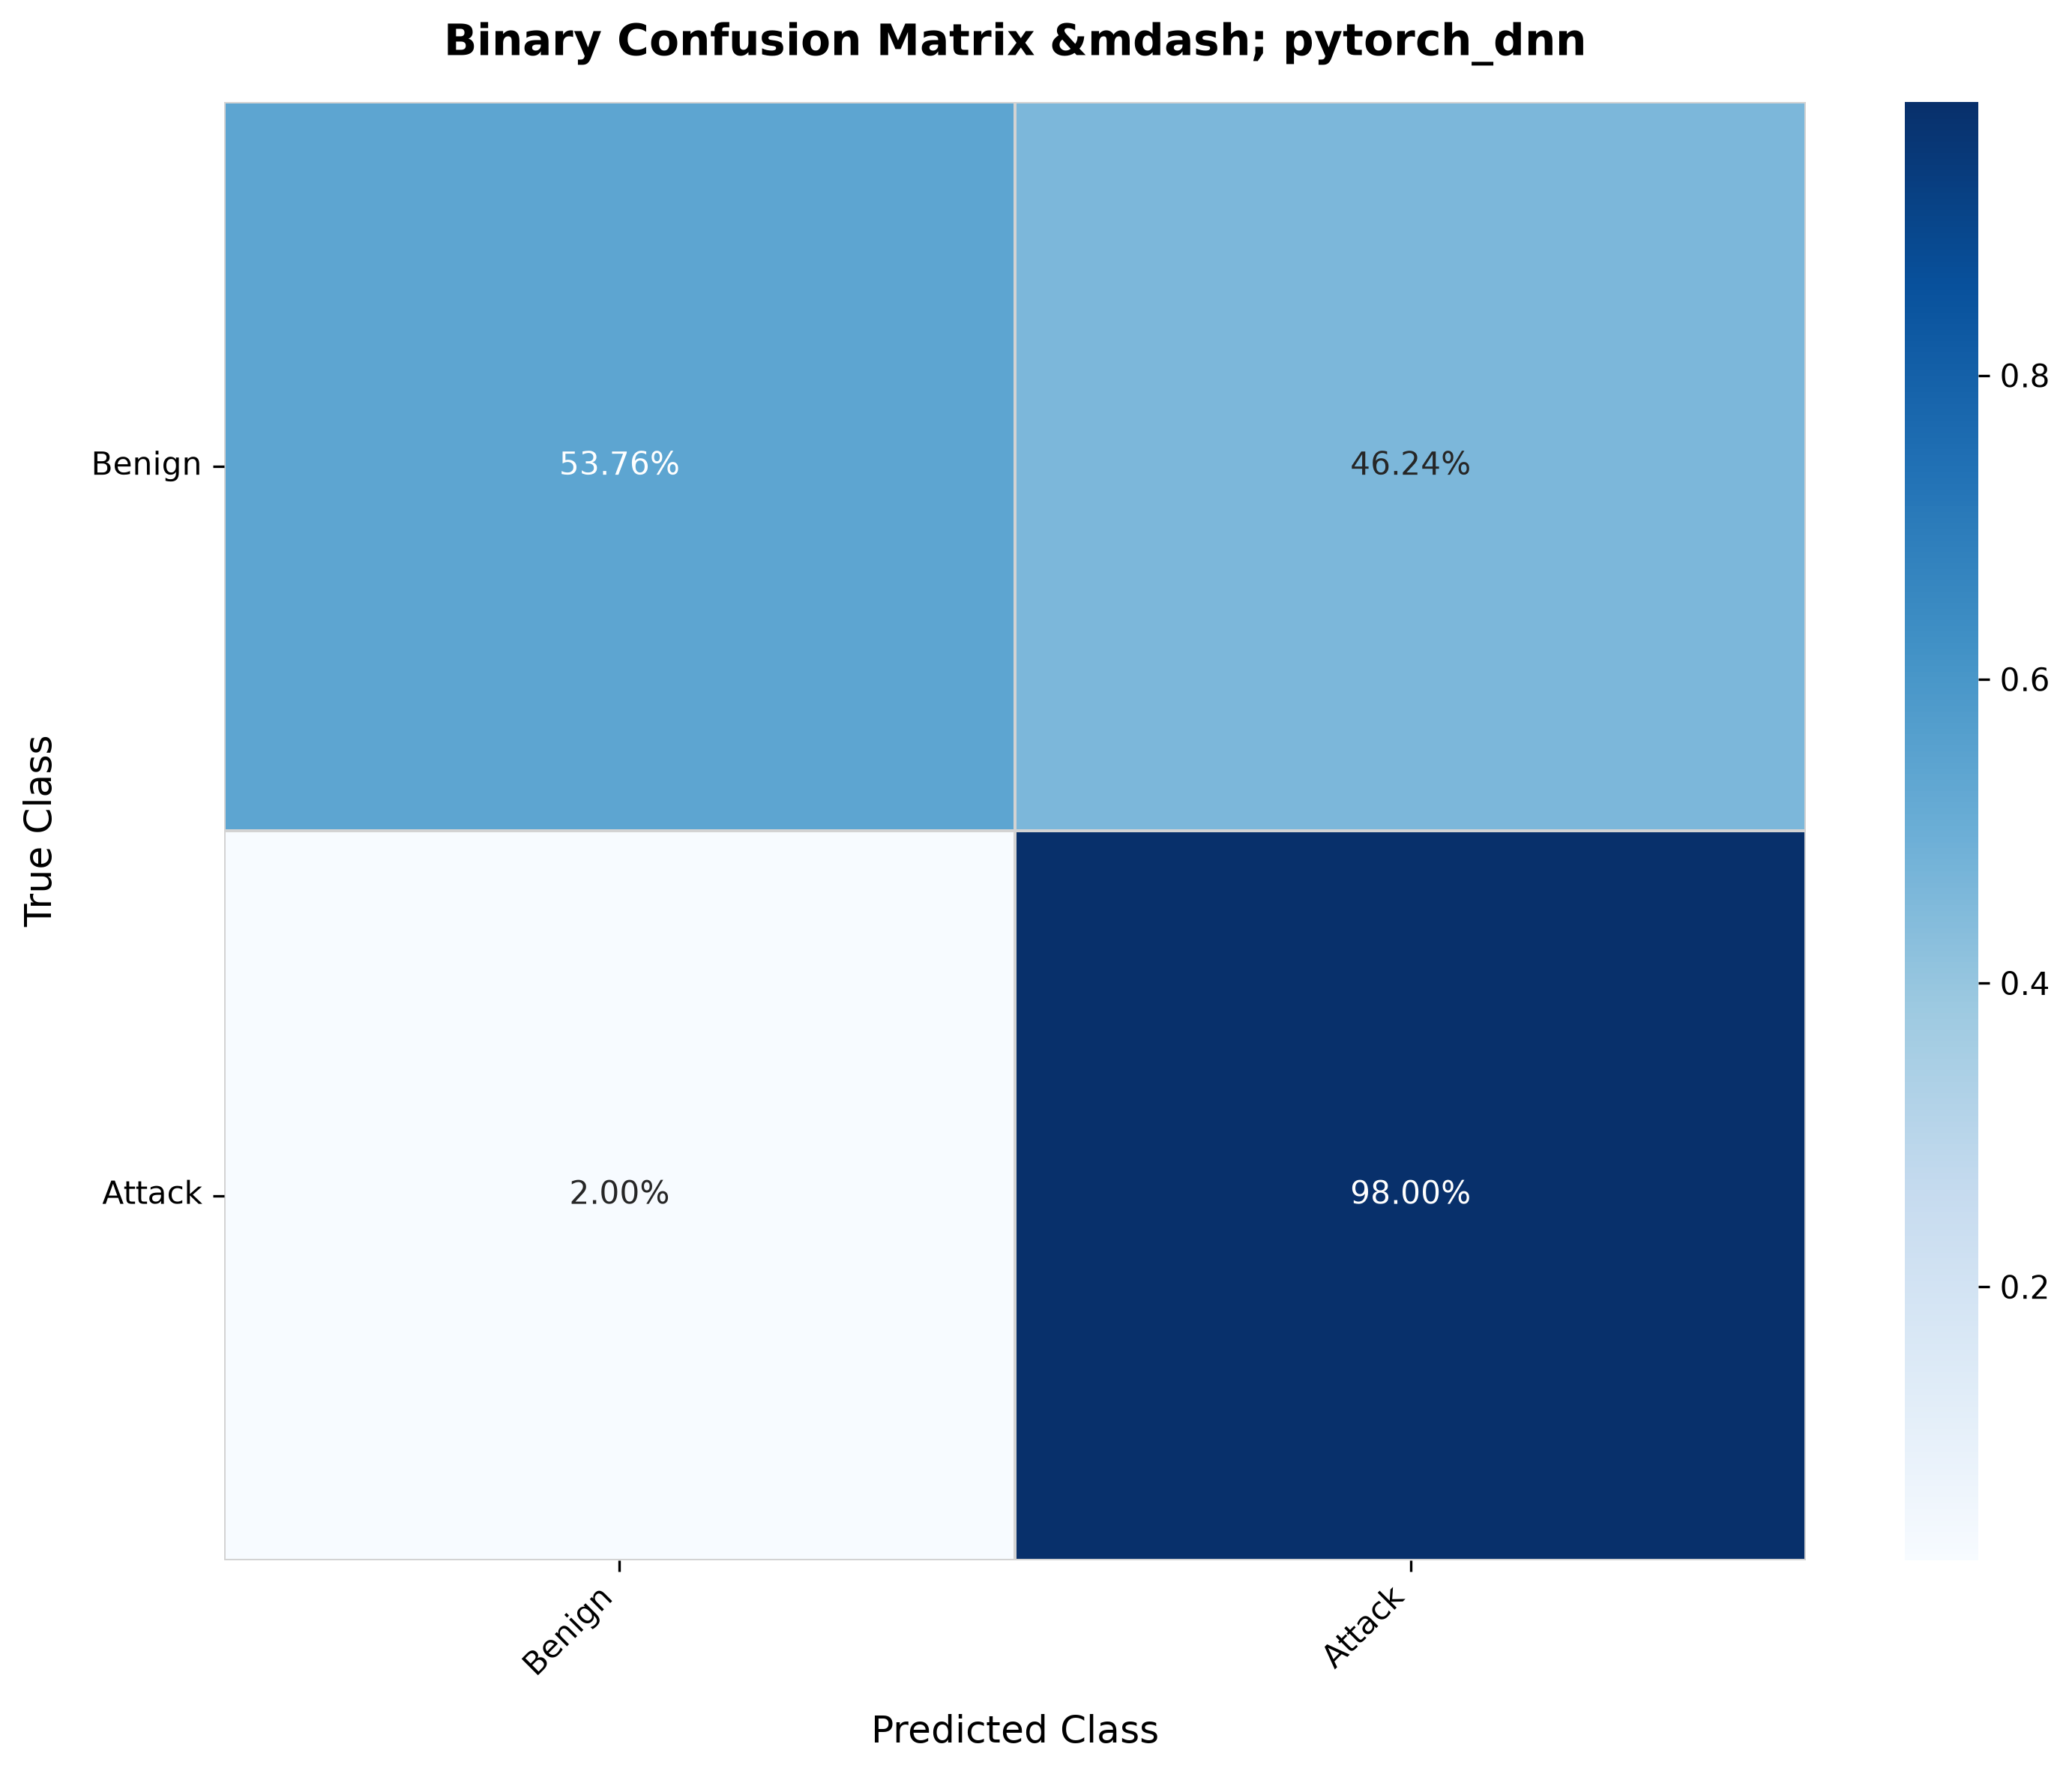

Displaying: binary_cm_random_forest.png


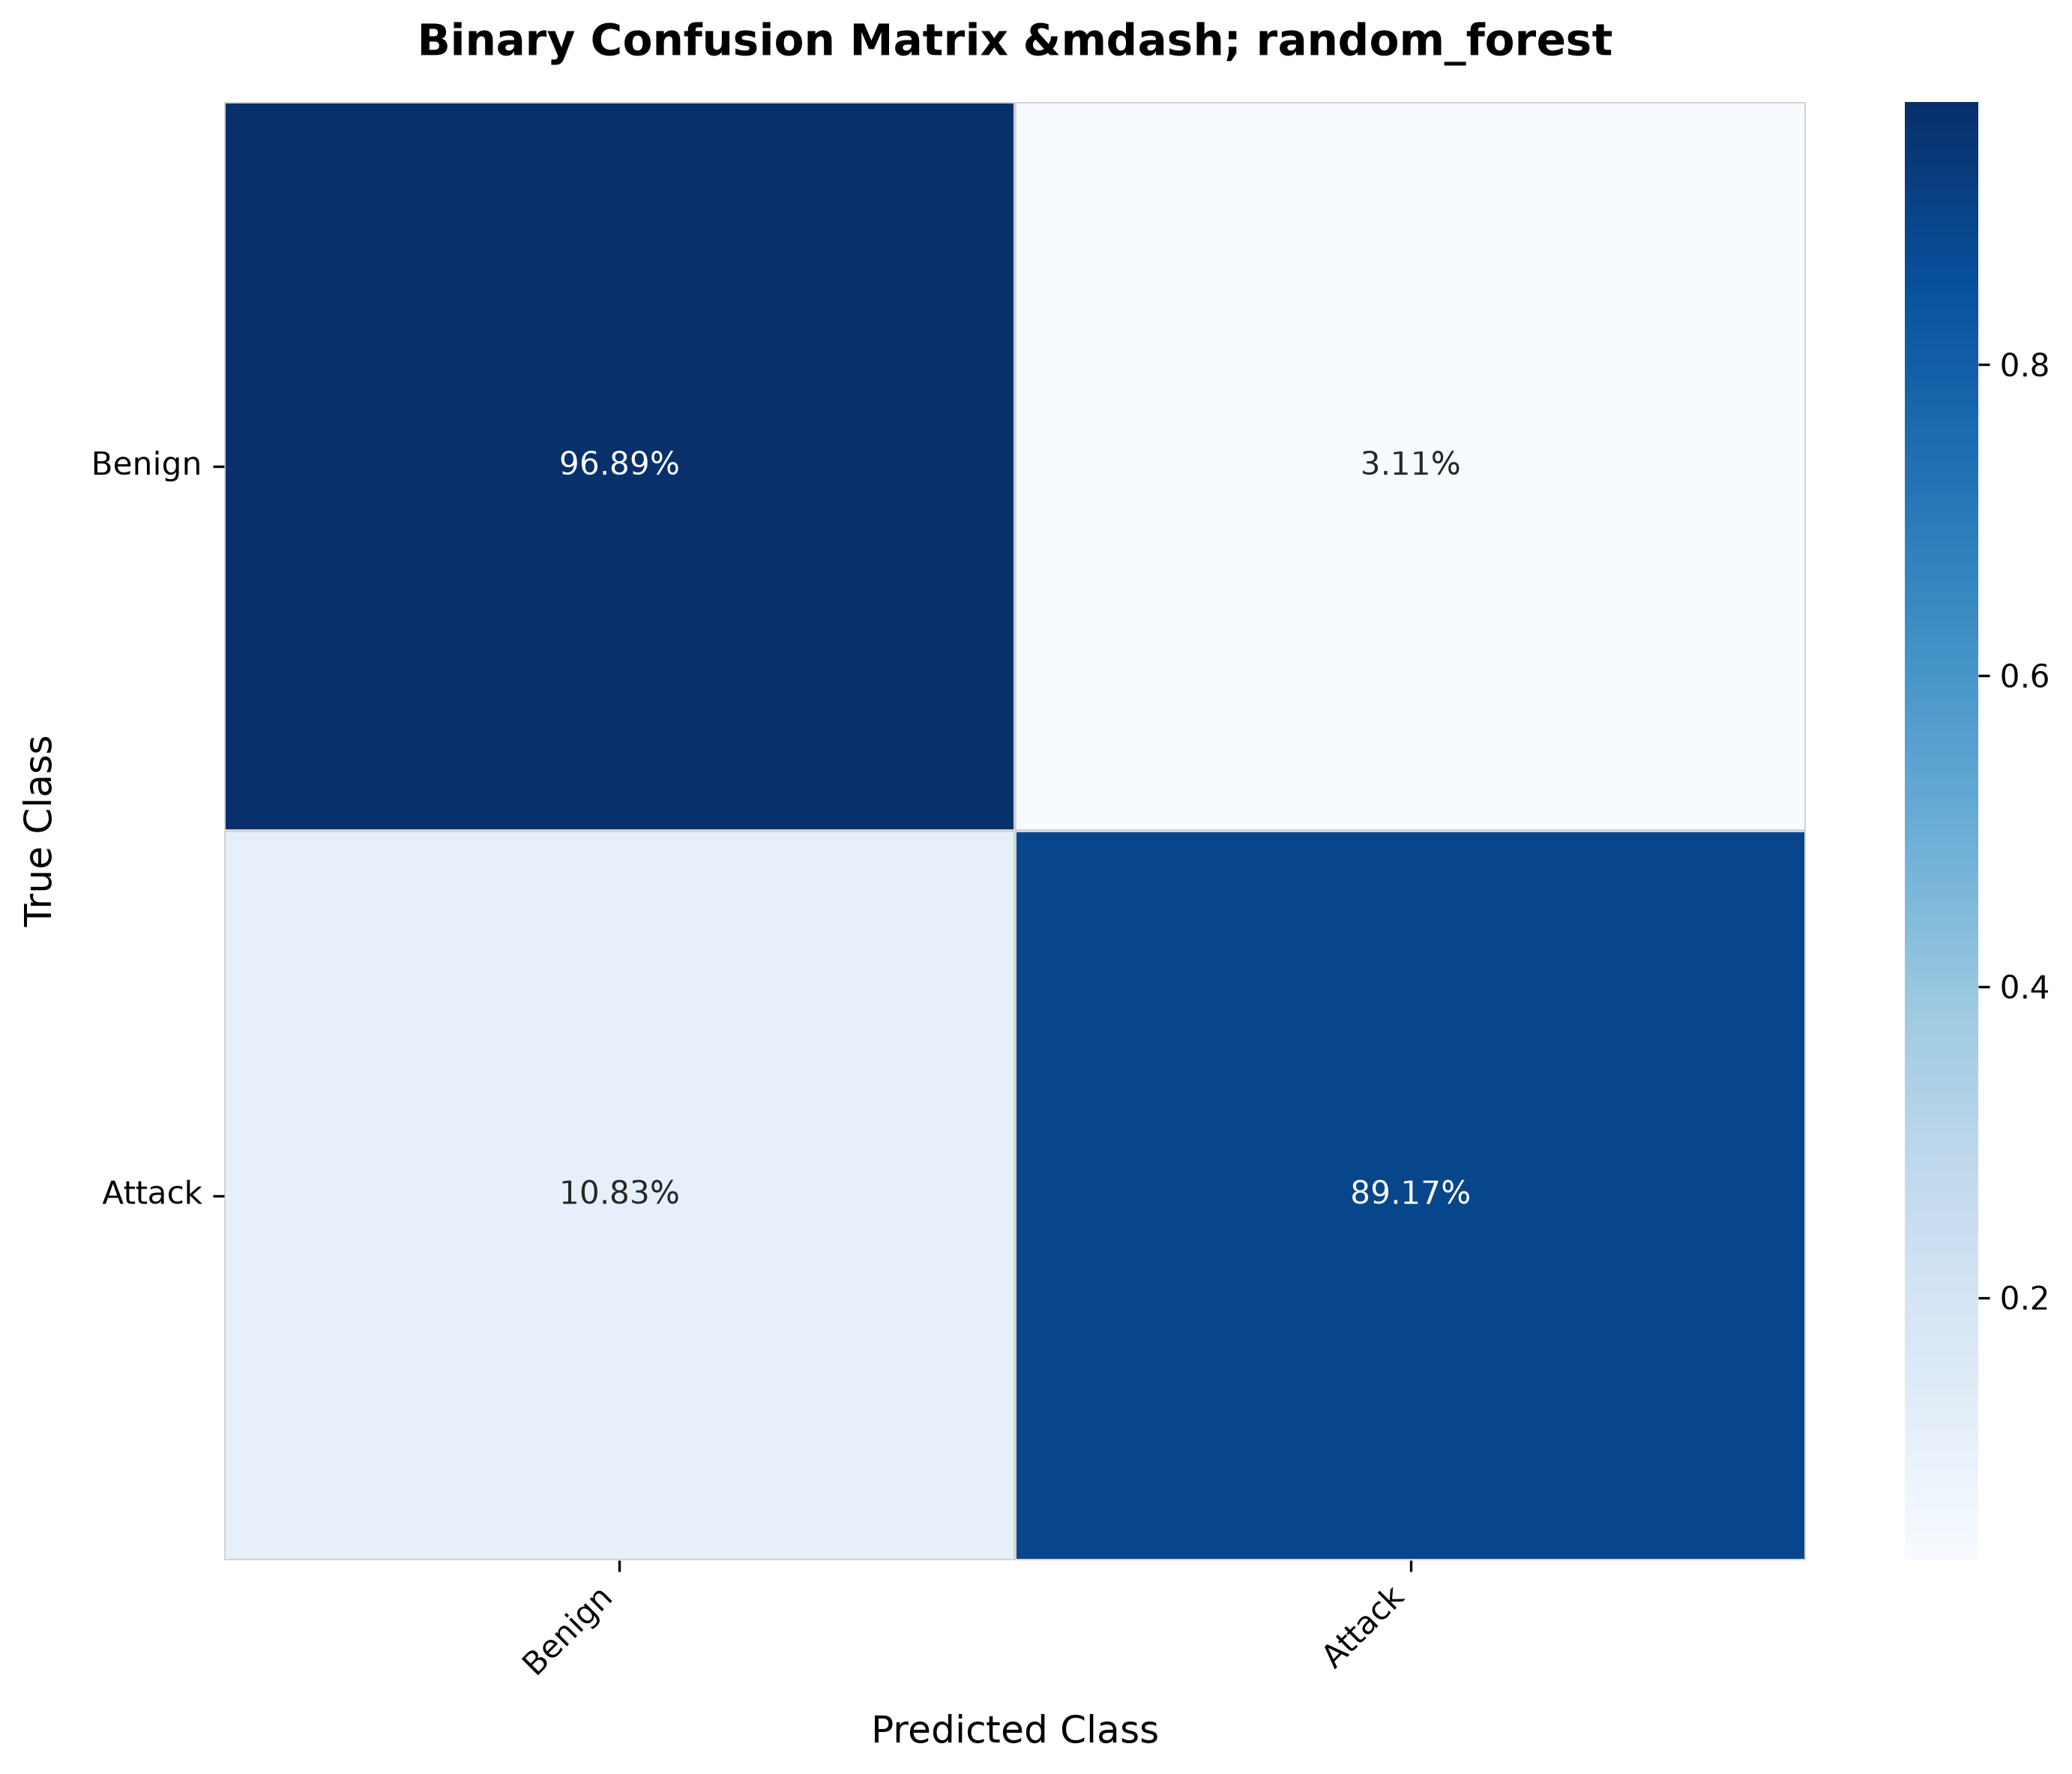

Displaying: binary_cm_xgboost.png


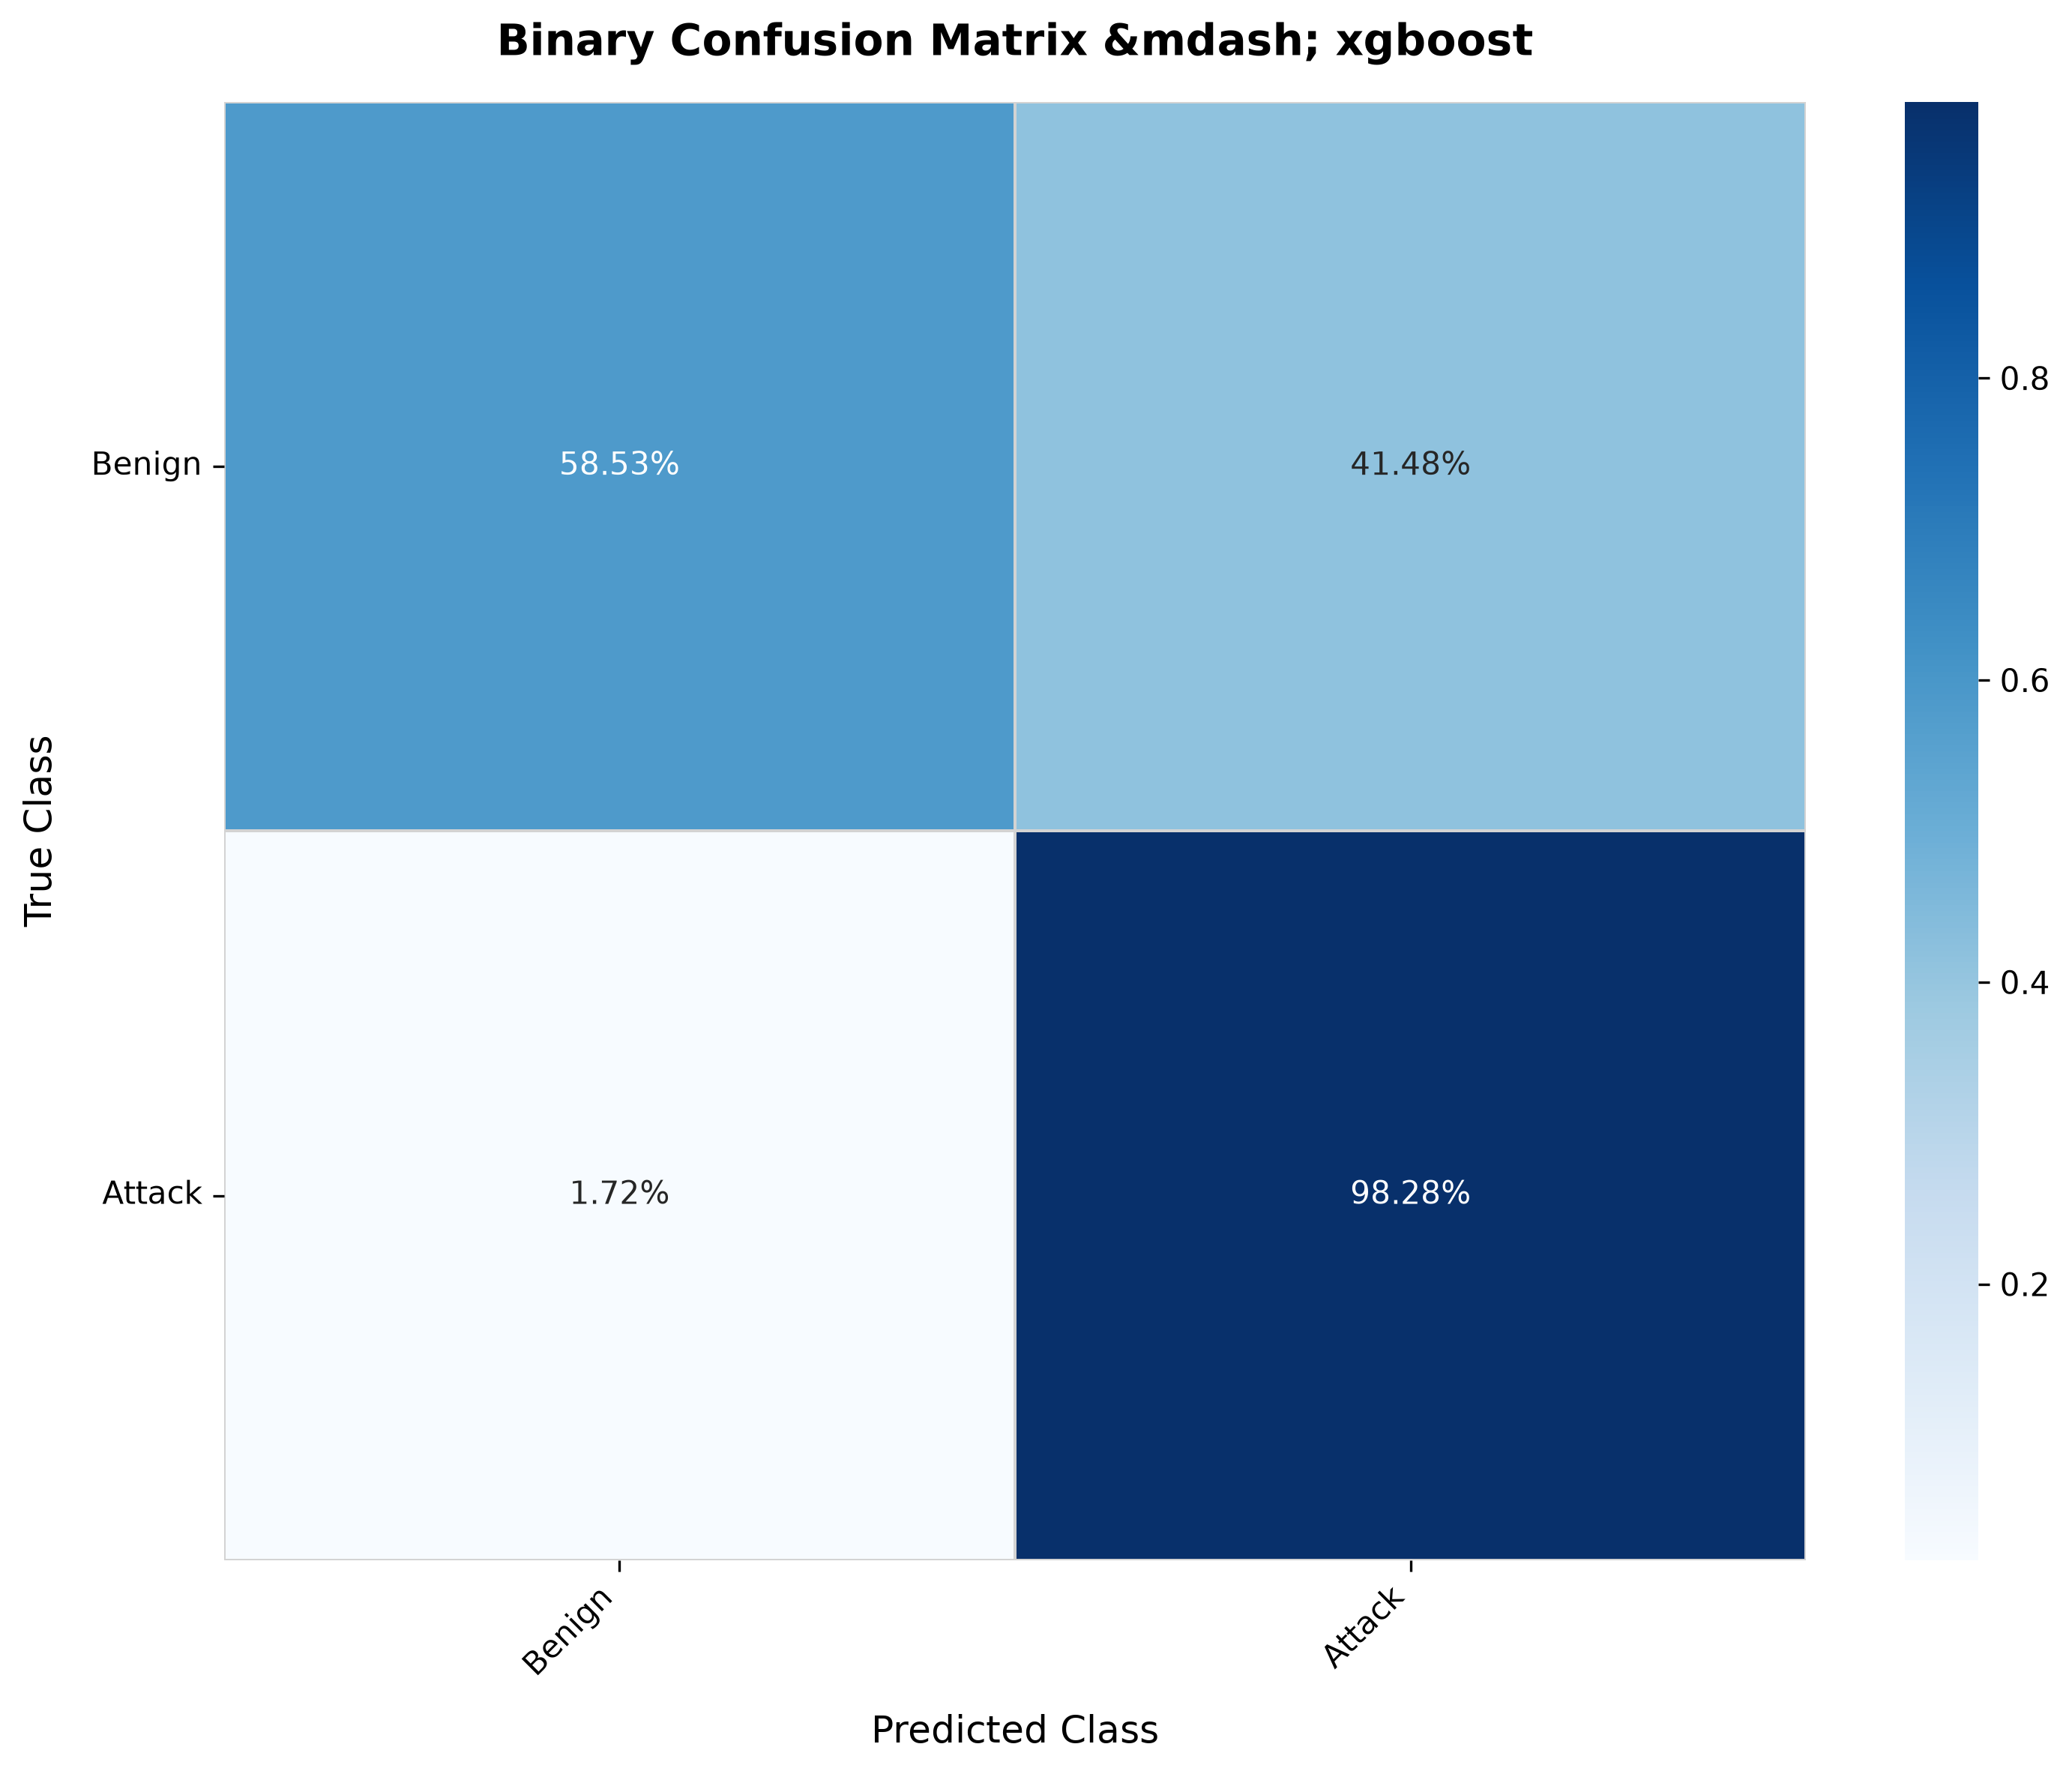

In [5]:
from IPython.display import Image, display

cm_files = sorted(list(FIGURES_DIR.glob("binary_cm_*.png")))
print(f"Found {len(cm_files)} confusion matrix figures:")
for cm_f in cm_files:
    print(f"Displaying: {cm_f.name}")
    display(Image(filename=str(cm_f), width=600))

## 5. ROC and Precision-Recall Curves

Found 5 ROC/PR curve figures:
Displaying: binary_roc_pr_lightgbm.png


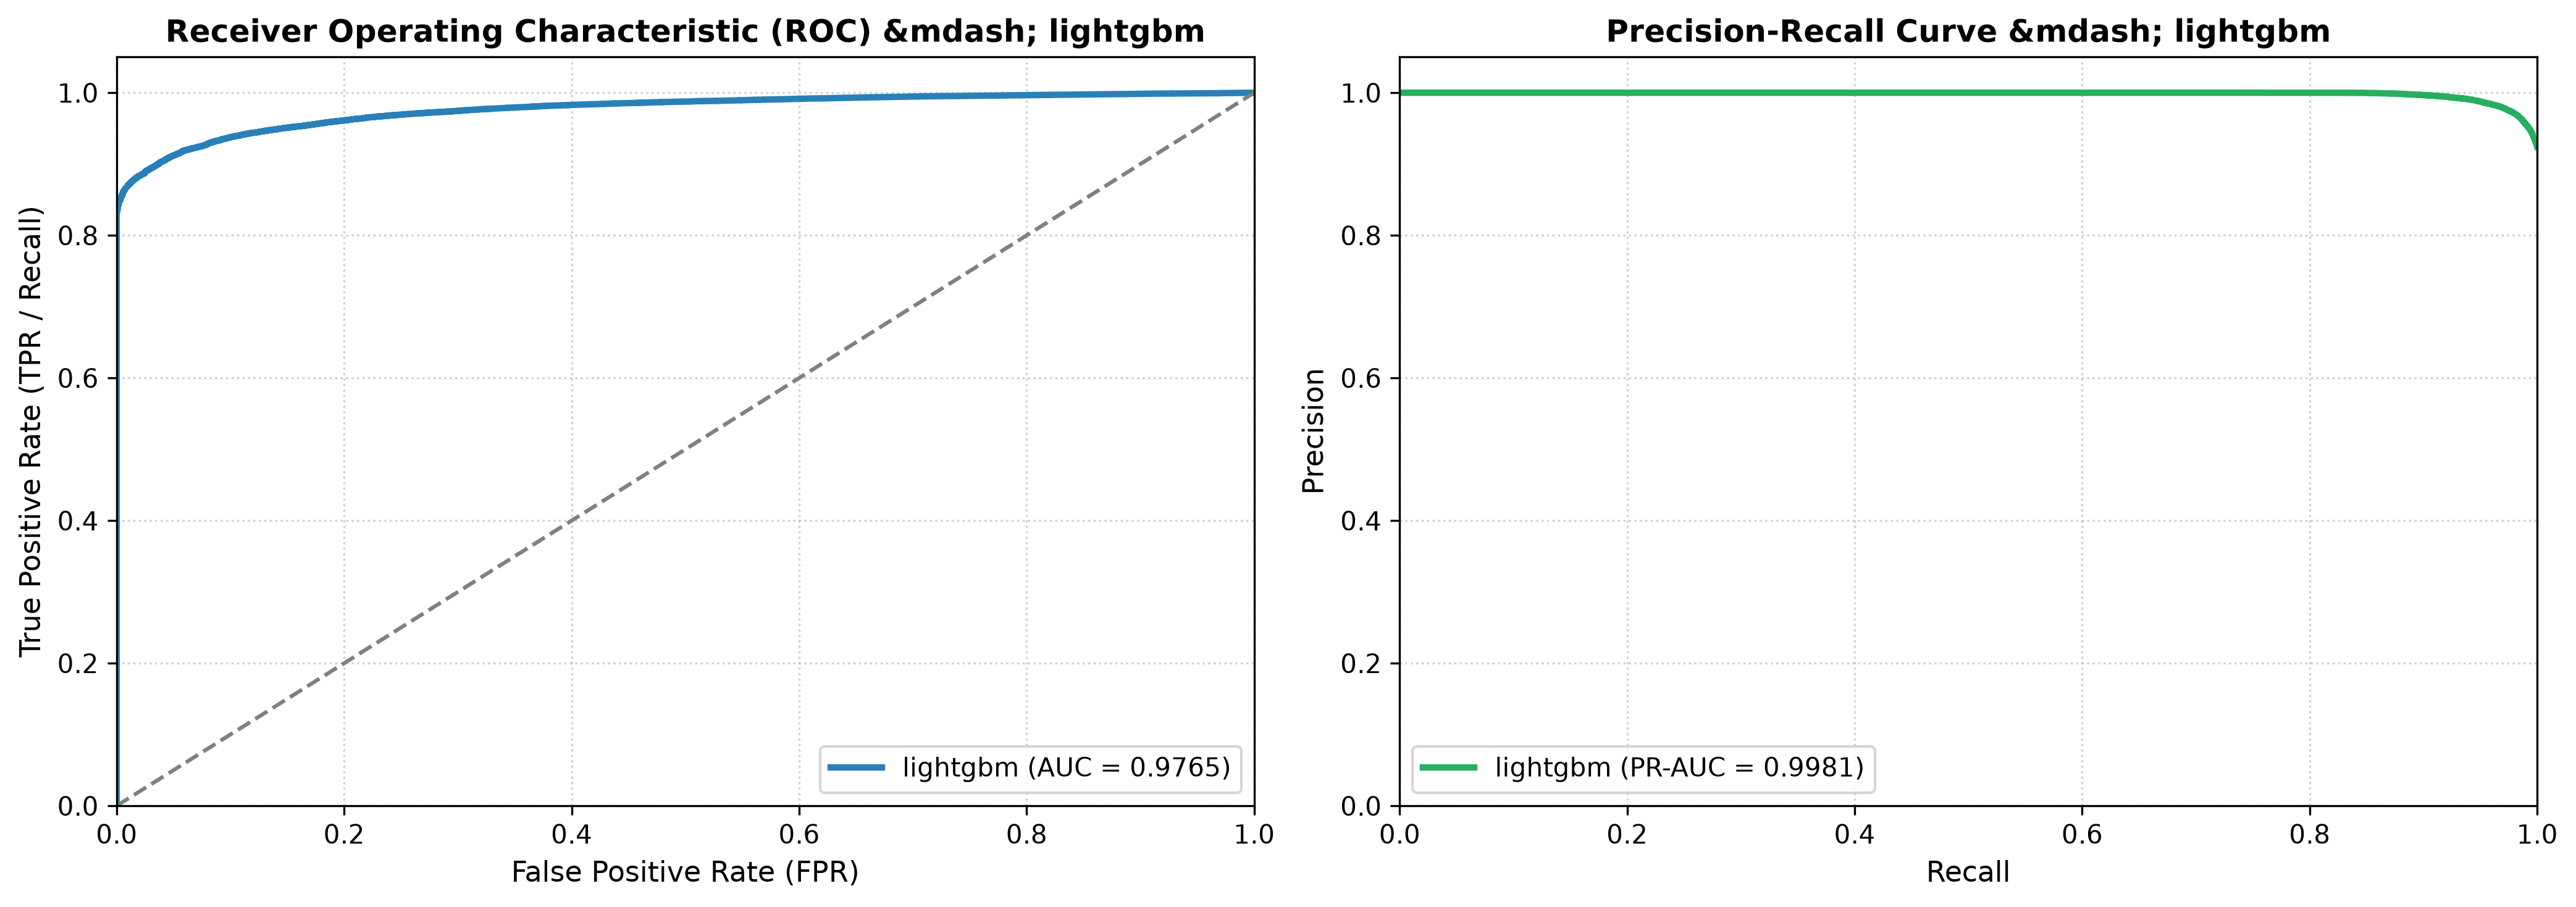

Displaying: binary_roc_pr_logistic_regression.png


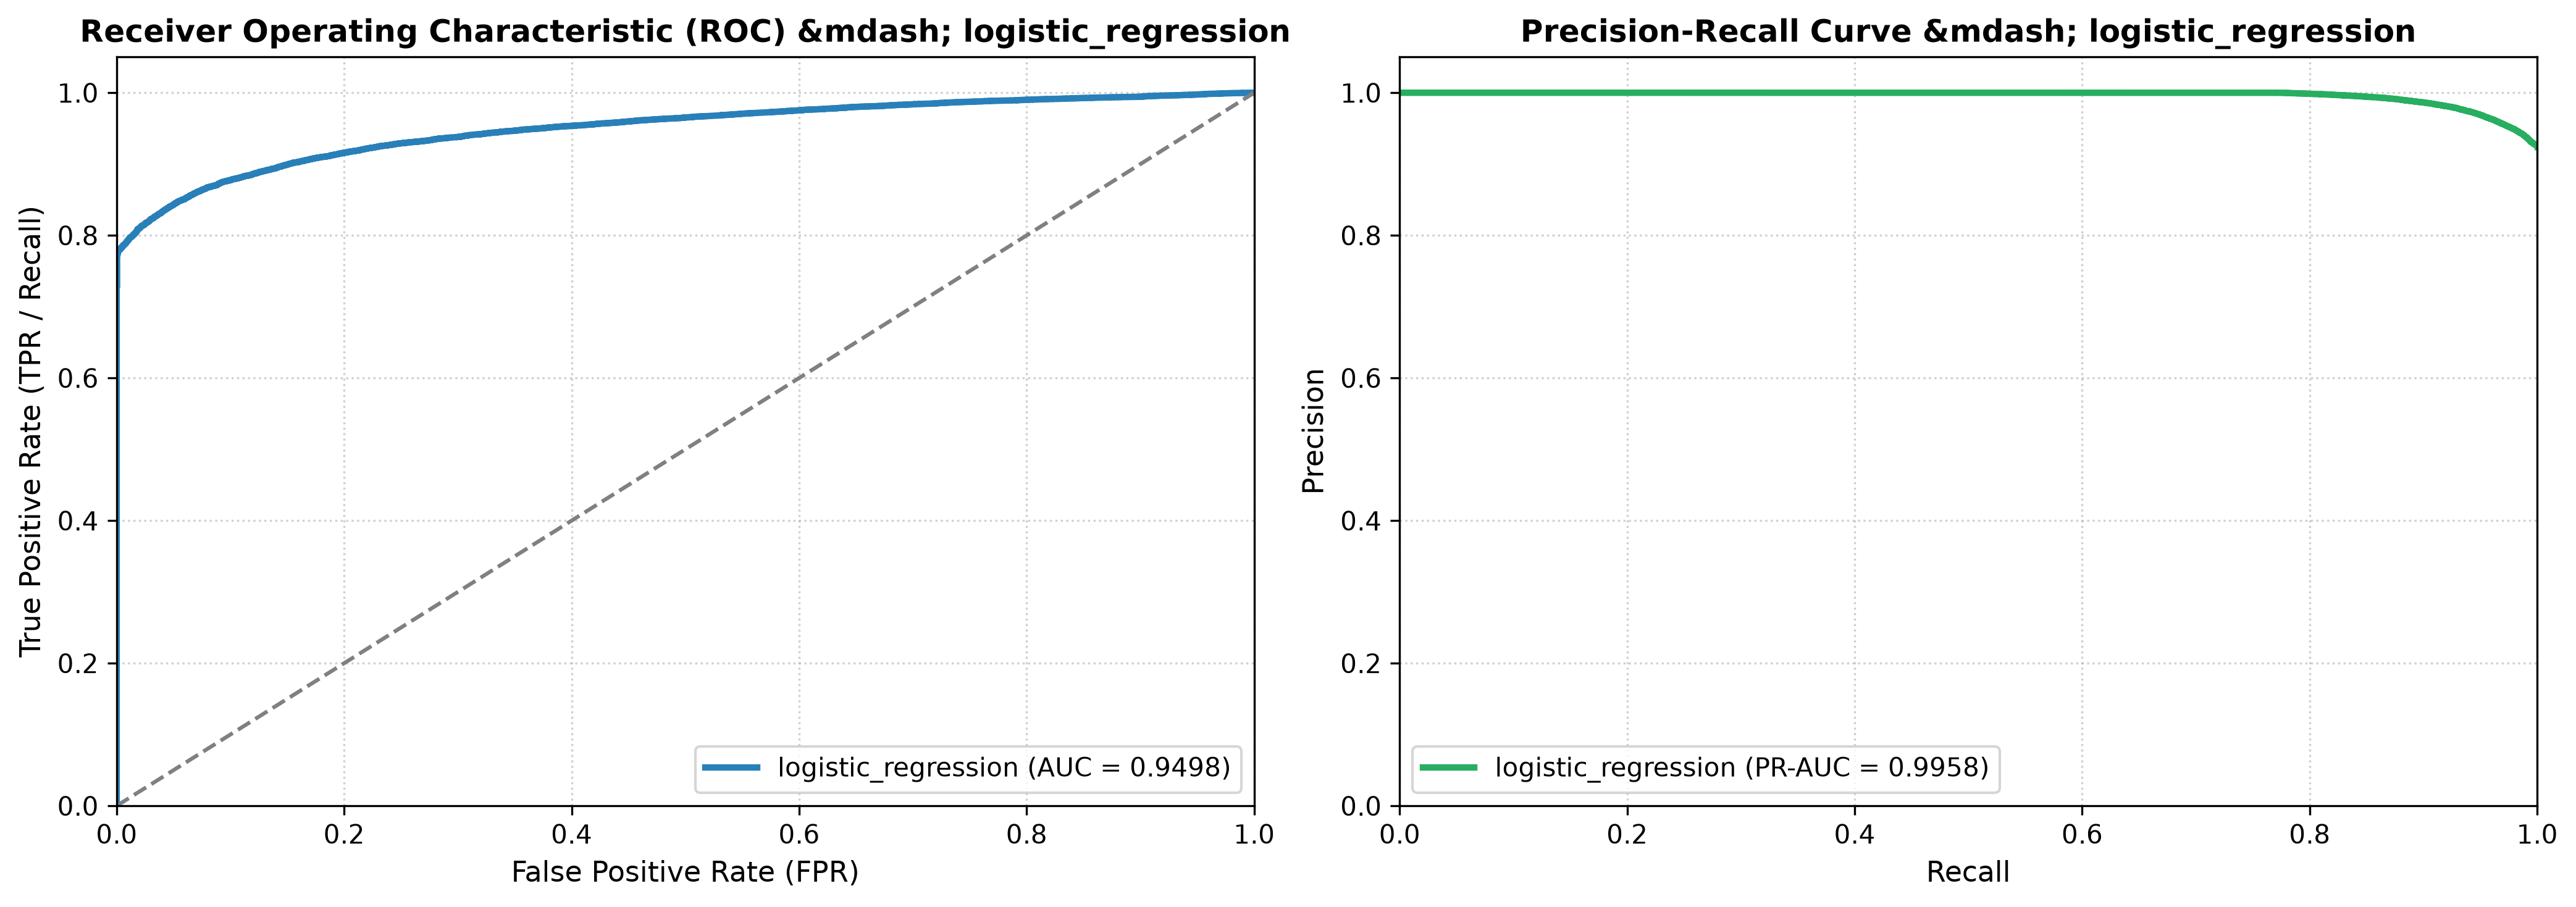

Displaying: binary_roc_pr_pytorch_dnn.png


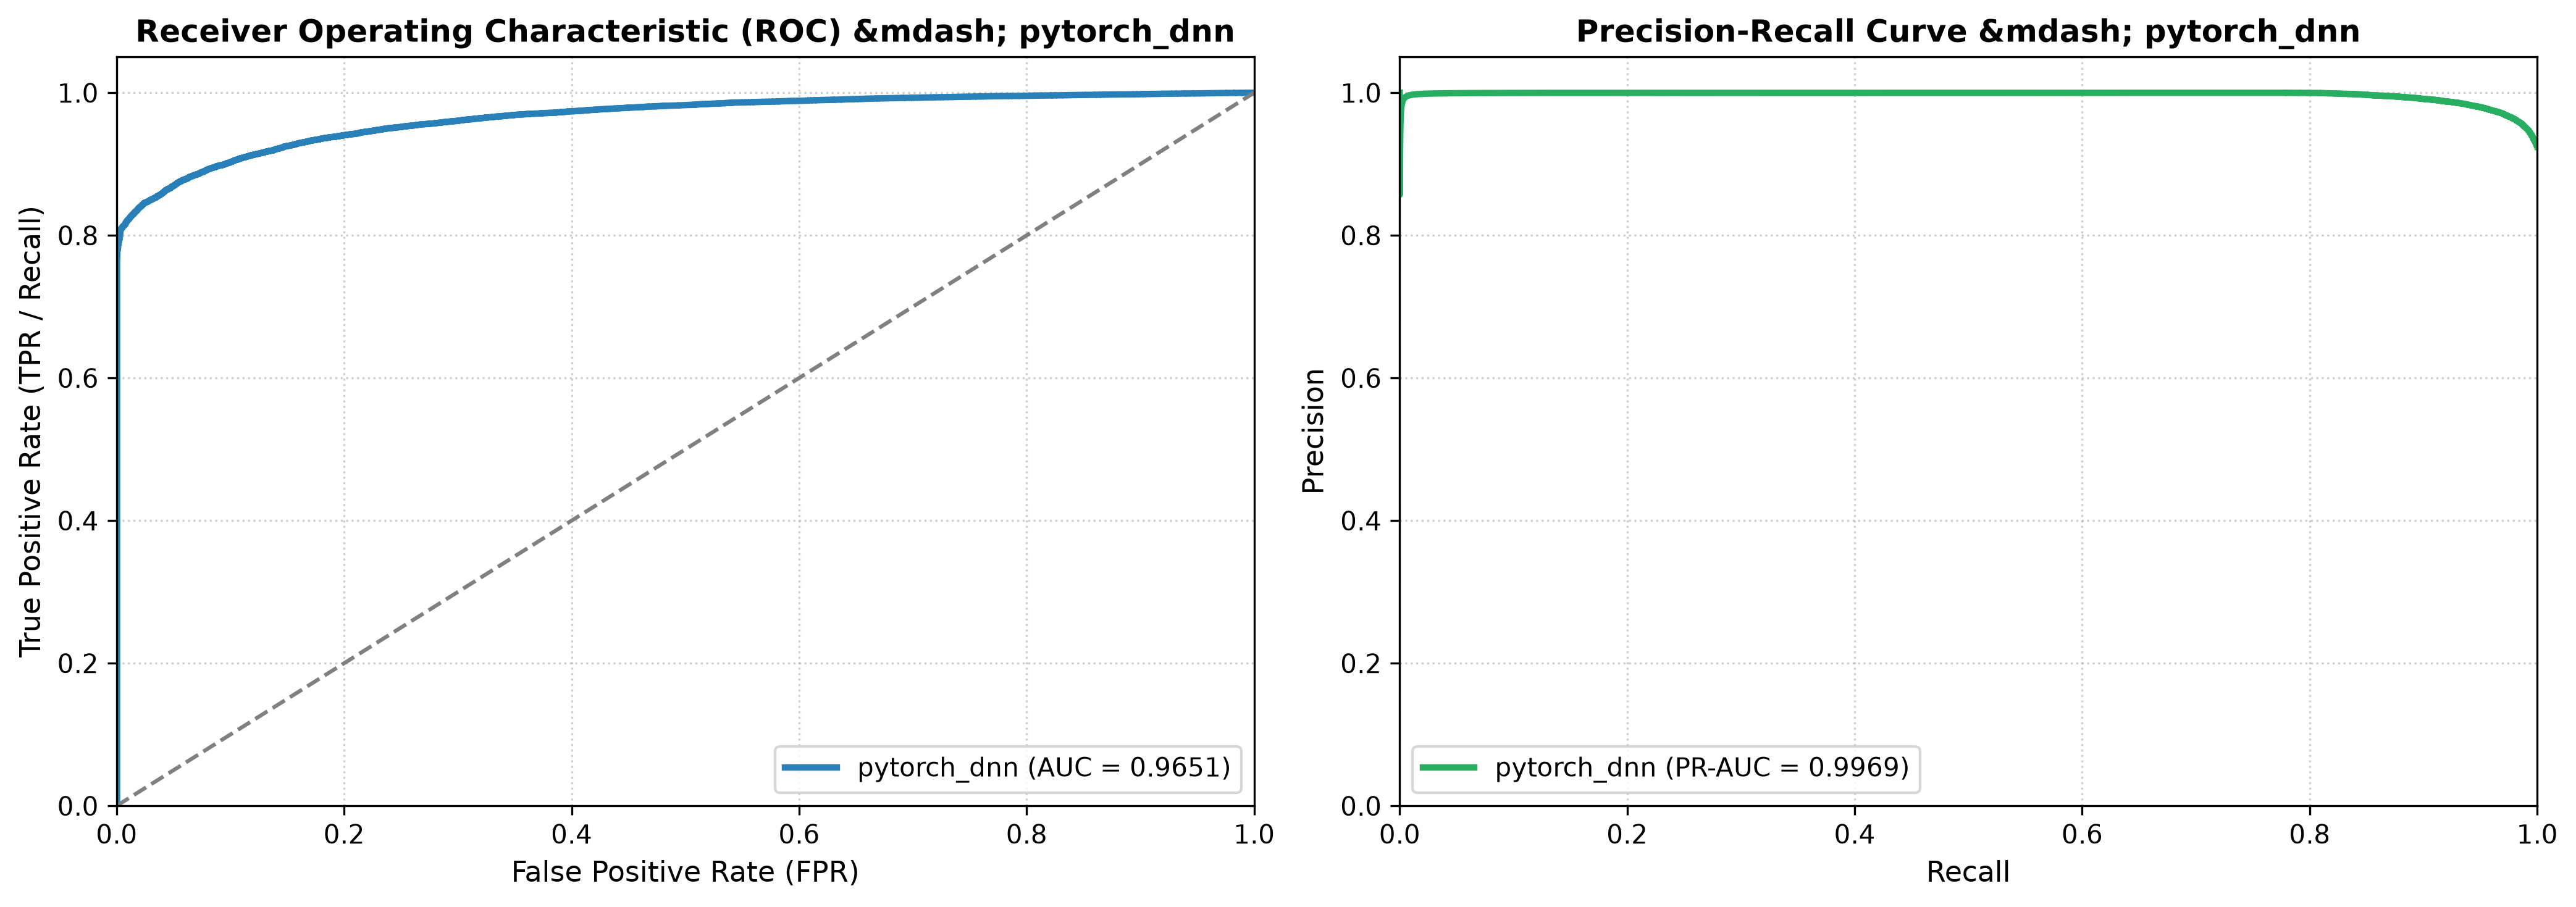

Displaying: binary_roc_pr_random_forest.png


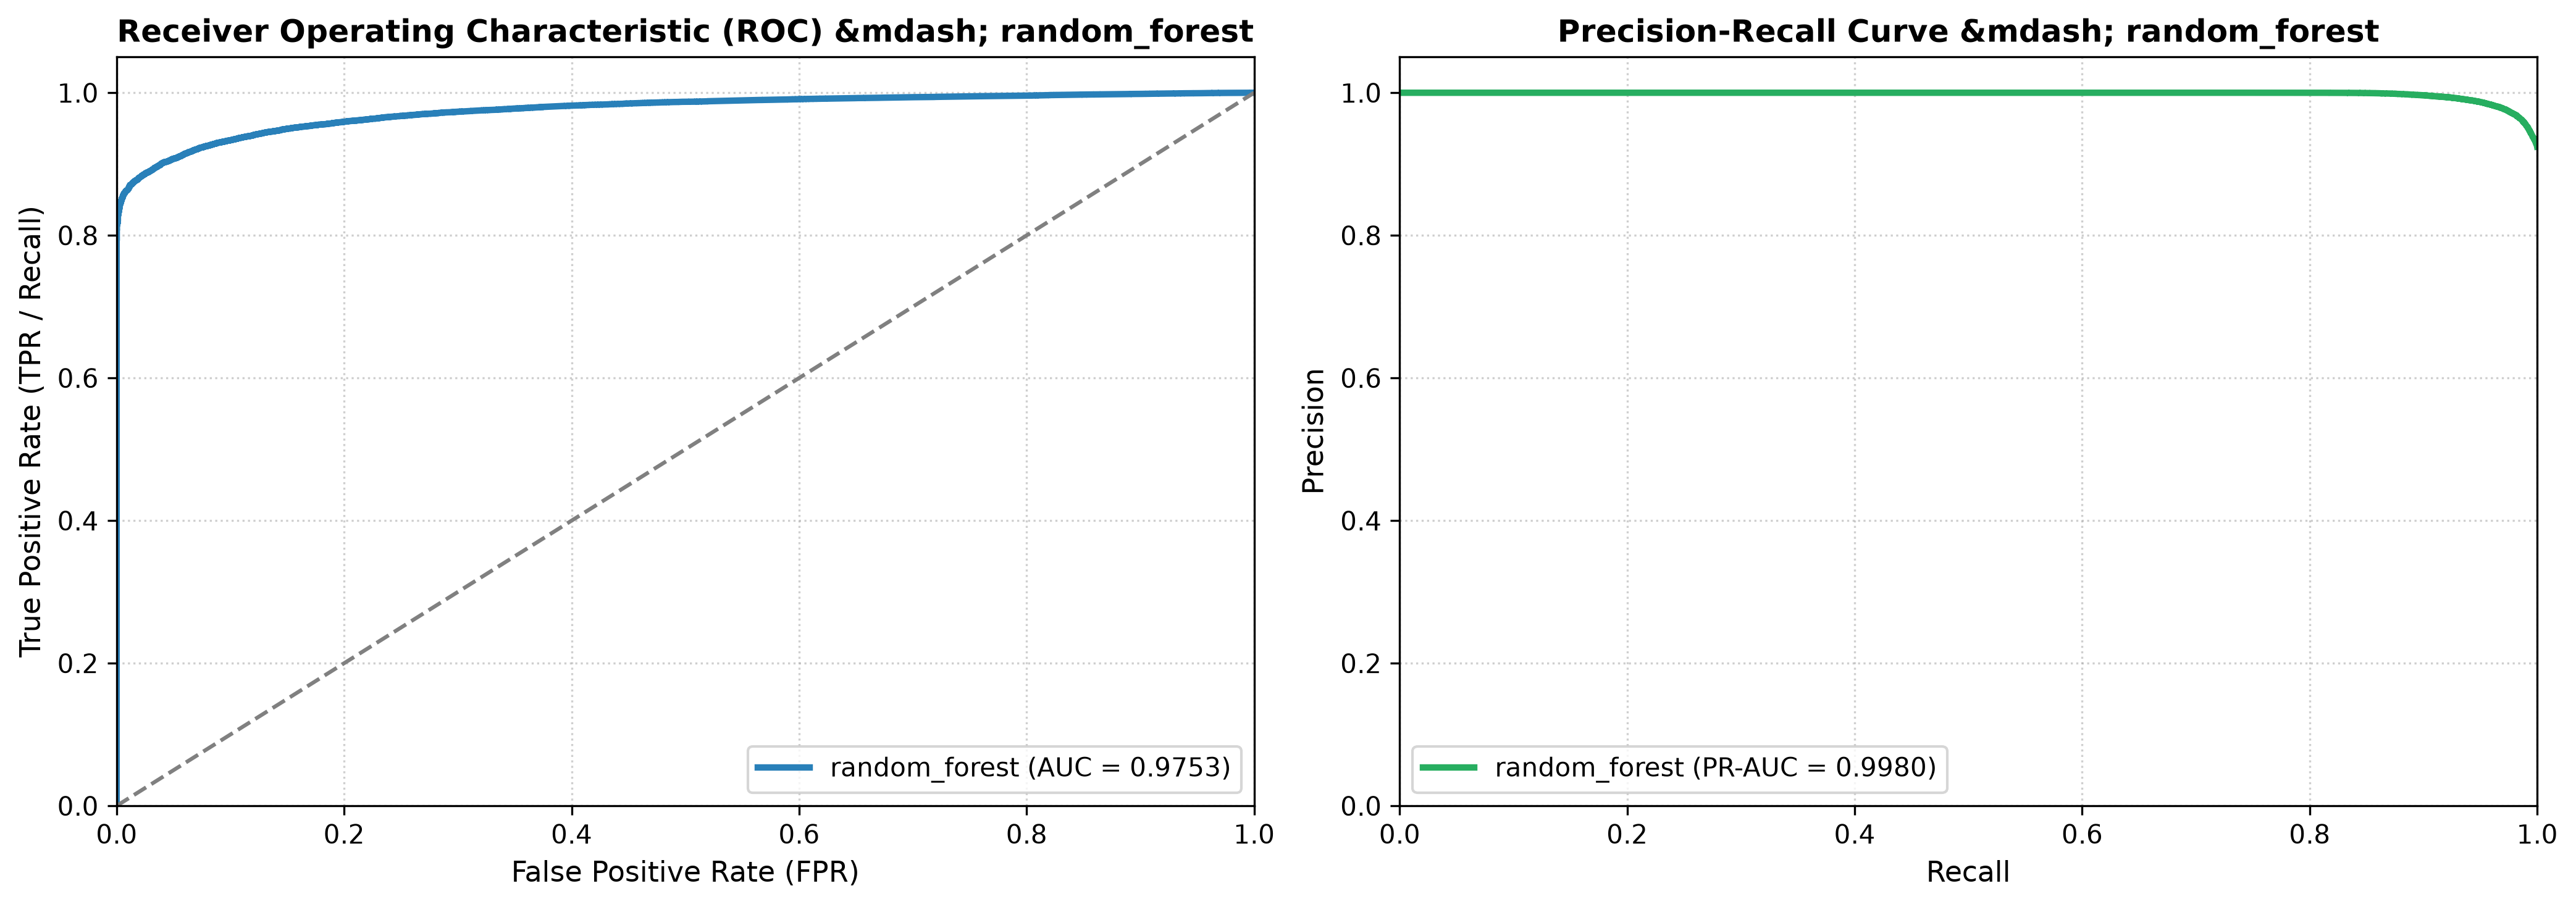

Displaying: binary_roc_pr_xgboost.png


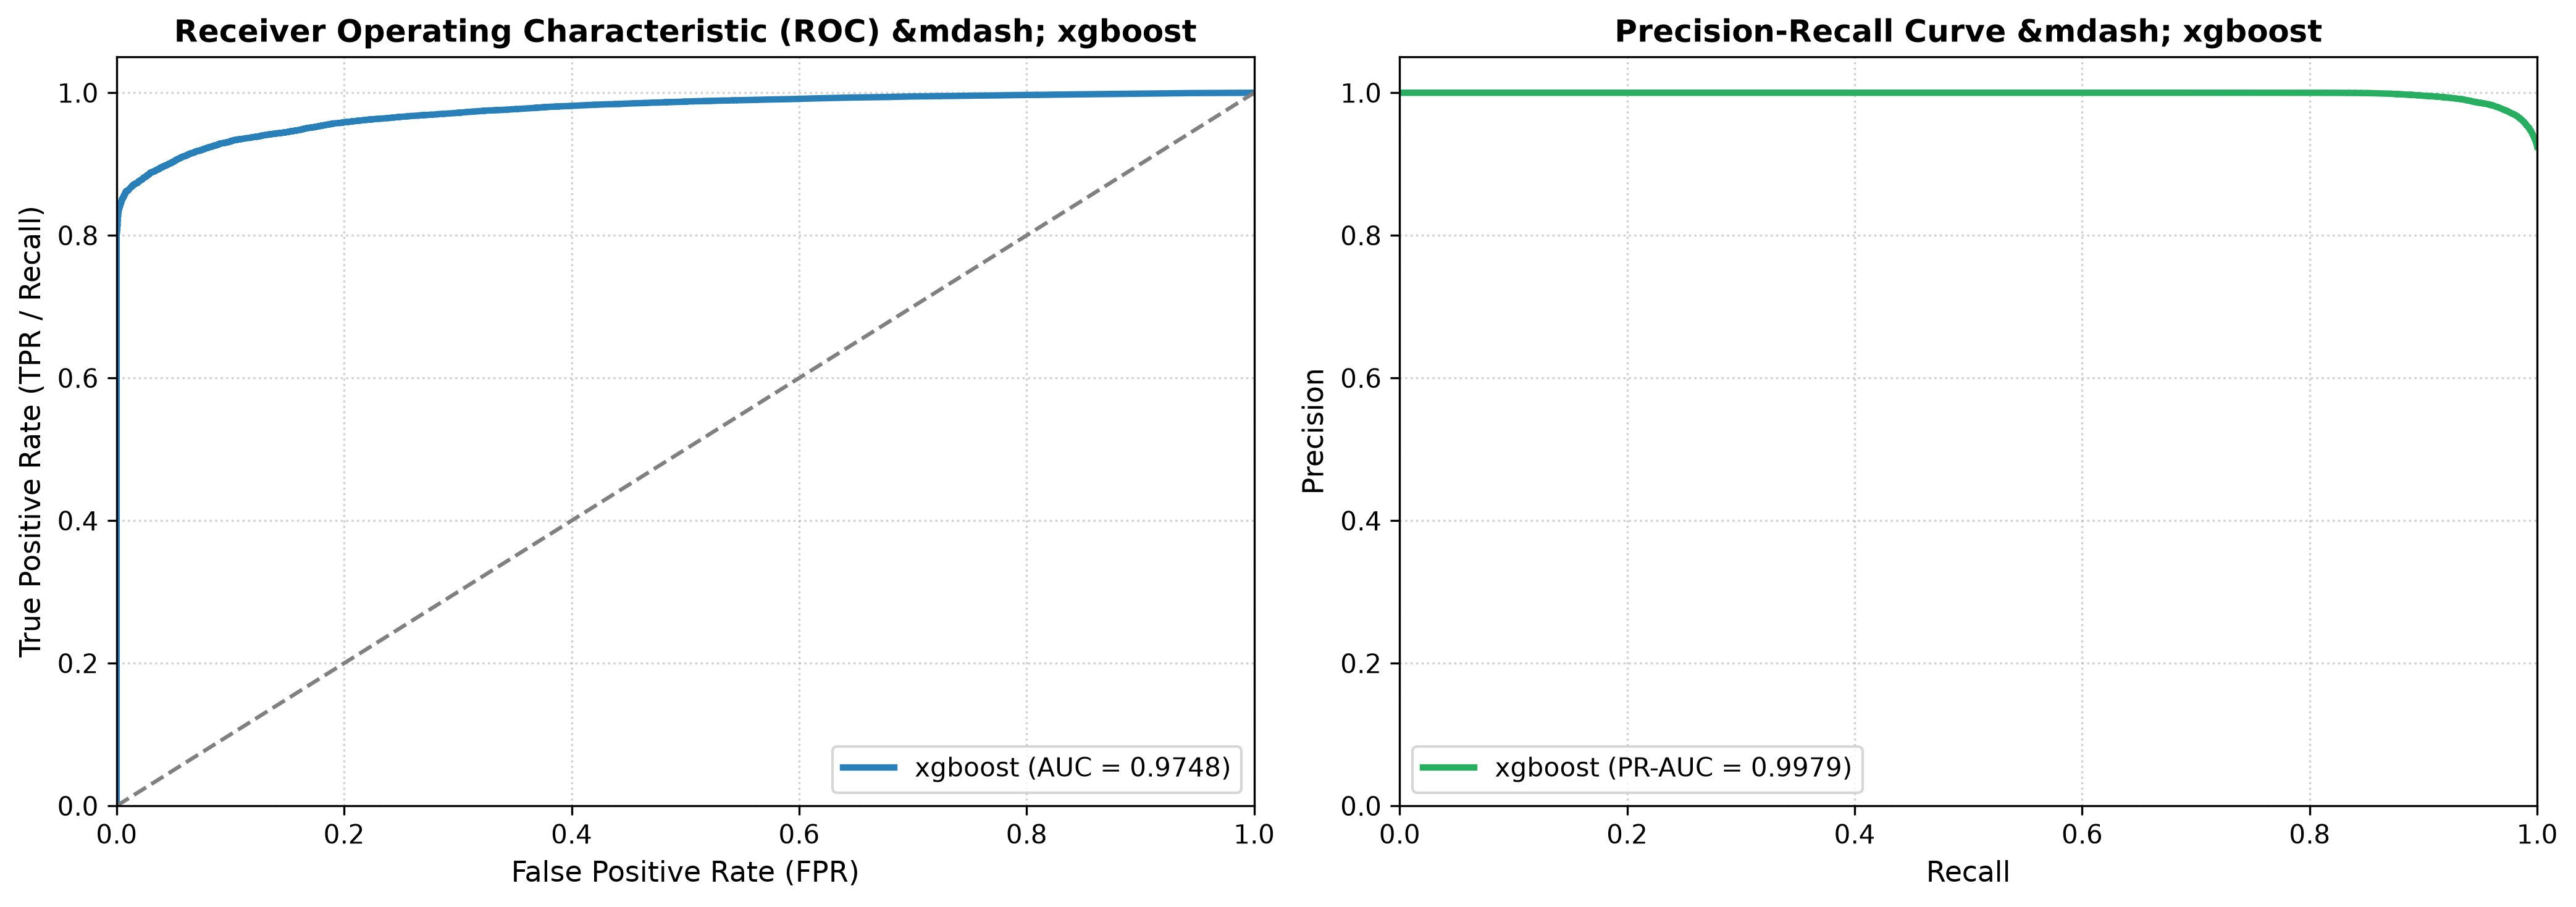

In [6]:
roc_files = sorted(list(FIGURES_DIR.glob("binary_roc_pr_*.png")))
print(f"Found {len(roc_files)} ROC/PR curve figures:")
for rf in roc_files:
    print(f"Displaying: {rf.name}")
    display(Image(filename=str(rf), width=750))